# 📈 Analisi Comparativa Indici Azionari Globali (2020–2025)

Analisi esplorativa e comparativa dei principali indici azionari globali nel periodo 2020–2025.  
I dati sono scaricati in tempo reale tramite la libreria **yfinance** (Yahoo Finance API).

| Attributo | Dettaglio |
|---|---|
| Periodo | 6 gennaio 2020 – 30 dicembre 2025 |
| Granularità | Giornaliera per indice |
| Indici | S&P 500 · Nikkei 225 · DAX · FTSE MIB · CAC 40 · FTSE 100 |

## 📦 EDA e preparazione dei dati

### Download e struttura
`yfinance` restituisce un DataFrame con **MultiIndex** sulle colonne (Price × Ticker).  
Per l'analisi viene estratto solo il livello `Close` e i ticker vengono rinominati con i nomi estesi.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

#oggi = dt.date.today() meglio fissare una data stock
INDICI_TICKERS = ["^GSPC","FTSEMIB.MI","^GDAXI","^FCHI","^N225","^FTSE"]
df = yf.download(INDICI_TICKERS, start="2020-01-01", end="2025-12-31")
df

[*********************100%***********************]  6 of 6 completed


Price           Close                                                       \
Ticker     FTSEMIB.MI        ^FCHI        ^FTSE        ^GDAXI        ^GSPC   
Date                                                                         
2020-01-02    23836.0  6041.500000  7604.299805  13385.929688  3257.850098   
2020-01-03    23702.0  6044.160156  7622.399902  13219.139648  3234.850098   
2020-01-06    23581.0  6013.589844  7575.299805  13126.990234  3246.280029   
2020-01-07    23723.0  6012.350098  7573.899902  13226.830078  3237.179932   
2020-01-08    23832.0  6031.000000  7574.899902  13320.179688  3253.050049   
...               ...          ...          ...           ...          ...   
2025-12-24        NaN  8103.580078  9870.700195           NaN  6932.049805   
2025-12-25        NaN          NaN          NaN           NaN          NaN   
2025-12-26        NaN          NaN          NaN           NaN  6929.939941   
2025-12-29    44436.0  8112.020020  9866.500000  24351.119141  6905.740234   
2025-12-30    44945.0  8168.149902  9940.700195  24490.410156  6896.240234   

Price                          High                                          \
Ticker             ^N225 FTSEMIB.MI        ^FCHI        ^FTSE        ^GDAXI   
Date                                                                          
2020-01-02           NaN    23862.0  6062.919922  7624.799805  13425.030273   
2020-01-03           NaN    23760.0  6044.160156  7626.399902  13282.740234   
2020-01-06  23204.859375    23608.0  6017.970215  7622.399902  13143.110352   
2020-01-07  23575.720703    23794.0  6065.740234  7604.600098  13283.879883   
2020-01-08  23204.759766    23893.0  6031.000000  7579.500000  13334.040039   
...                  ...        ...          ...          ...           ...   
2025-12-24  50344.101562        NaN  8135.709961  9893.200195           NaN   
2025-12-25  50407.789062        NaN          NaN          NaN           NaN   
2025-12-26  50750.390625        NaN          NaN          NaN           NaN   
2025-12-29  50526.921875    44660.0  8132.589844  9892.799805  24389.150391   
2025-12-30  50339.480469    45005.0  8184.029785  9954.299805  24527.939453   

Price       ...         Open                                           \
Ticker      ...        ^FTSE        ^GDAXI        ^GSPC         ^N225   
Date        ...                                                         
2020-01-02  ...  7542.399902  13233.709961  3244.669922           NaN   
2020-01-03  ...  7604.299805  13266.389648  3226.360107           NaN   
2020-01-06  ...  7622.399902  13085.490234  3217.550049  23319.759766   
2020-01-07  ...  7575.299805  13199.589844  3241.860107  23320.119141   
2020-01-08  ...  7573.899902  13140.490234  3238.590088  23217.490234   
...         ...          ...           ...          ...           ...   
2025-12-24  ...  9889.200195           NaN  6904.910156  50475.480469   
2025-12-25  ...          NaN           NaN          NaN  50450.179688   
2025-12-26  ...          NaN           NaN  6936.020020  50527.128906   
2025-12-29  ...  9870.700195  24370.939453  6903.600098  50691.218750   
2025-12-30  ...  9866.500000  24343.189453  6900.439941  50312.851562   

Price            Volume                                                     \
Ticker       FTSEMIB.MI       ^FCHI        ^FTSE      ^GDAXI         ^GSPC   
Date                                                                         
2020-01-02  264537200.0  63958300.0  482206700.0  75341400.0  3.459930e+09   
2020-01-03  325924900.0  60488000.0  475628900.0  80793400.0  3.484700e+09   
2020-01-06  349155800.0  69063700.0  516783400.0  71778600.0  3.702460e+09   
2020-01-07  306340300.0  69593800.0  511576100.0  78282300.0  3.435910e+09   
2020-01-08  472506700.0  71431600.0  606225000.0  88178800.0  3.726840e+09   
...                 ...         ...          ...         ...           ...   
2025-12-24          NaN   8940000.0  163408500.0         NaN  1.798270e+09 

In [3]:
print(df.shape)
print(df.columns)
print(df.head())

(1561, 30)
MultiIndex([( 'Close', 'FTSEMIB.MI'),
            ( 'Close',      '^FCHI'),
            ( 'Close',      '^FTSE'),
            ( 'Close',     '^GDAXI'),
            ( 'Close',      '^GSPC'),
            ( 'Close',      '^N225'),
            (  'High', 'FTSEMIB.MI'),
            (  'High',      '^FCHI'),
            (  'High',      '^FTSE'),
            (  'High',     '^GDAXI'),
            (  'High',      '^GSPC'),
            (  'High',      '^N225'),
            (   'Low', 'FTSEMIB.MI'),
            (   'Low',      '^FCHI'),
            (   'Low',      '^FTSE'),
            (   'Low',     '^GDAXI'),
            (   'Low',      '^GSPC'),
            (   'Low',      '^N225'),
            (  'Open', 'FTSEMIB.MI'),
            (  'Open',      '^FCHI'),
            (  'Open',      '^FTSE'),
            (  'Open',     '^GDAXI'),
            (  'Open',      '^GSPC'),
            (  'Open',      '^N225'),
            ('Volume', 'FTSEMIB.MI'),
            ('Volume',      '^FCHI'),
 

In [4]:
#ci servono solo i prezzi di chiusura, quindi:
df_close = df["Close"].copy()
df_close.columns = ['FTSE MIB', 'CAC 40', 'FTSE 100', 'DAX', 'S&P 500', 'Nikkei 225']

### Gestione dei valori nulli
I valori nulli non rappresentano dati mancanti ma **giorni di chiusura dei mercati**, che non coincidono tra paesi diversi (festività nazionali differenti).  
Vengono gestiti con `ffill()` per nazione, nei giorni di chiusura il prezzo rimane quello dell'ultimo giorno di contrattazione.  
I NaN residui nelle prime righe (apertura del Nikkei posticipata) vengono rimossi con `dropna()`.

In [5]:
print(df_close.shape)
print(df_close.isnull().sum())

(1561, 6)
FTSE MIB      35
CAC 40        24
FTSE 100      48
DAX           33
S&P 500       54
Nikkei 225    96
dtype: int64


In [6]:
#Non sono dati mancanti nel senso classico, sono giorni di chiusura dei mercati che non coincidono tra paesi diversi
df_close = df_close.ffill()

# verifica
print(df_close.isnull().sum())

FTSE MIB      0
CAC 40        0
FTSE 100      0
DAX           0
S&P 500       0
Nikkei 225    2
dtype: int64


In [7]:
#il Nikkei ha NaN nelle prime righe (il 2 e 3 gennaio) il ffill non li copre perché non c'è un valore precedente da propagare.
#quindi:
df_close = df_close.dropna()

print(f"Righe dopo pulizia: {df_close.shape[0]}")
print(f"Periodo: {df_close.index[0].date()} → {df_close.index[-1].date()}")

Righe dopo pulizia: 1559
Periodo: 2020-01-06 → 2025-12-30


In [8]:
print(df_close.describe().round(2))

       FTSE MIB   CAC 40  FTSE 100       DAX  S&P 500  Nikkei 225
count   1559.00  1559.00   1559.00   1559.00  1559.00     1559.00
mean   28392.29  6780.65   7552.26  16455.80  4586.57    31597.13
std     6951.19  1010.69    924.23   3672.44  1025.72     7048.20
min    14894.00  3754.84   4993.90   8441.71  2237.40    16552.83
25%    23592.50  6131.35   7063.90  13831.90  3909.70    27104.32
50%    26968.00  7042.23   7507.10  15603.88  4384.63    29157.95
75%    33768.50  7547.80   8166.85  18425.87  5357.41    37869.89
max    44945.00  8258.86   9940.70  24611.25  6932.05    52411.34


### Normalizzazione
Per confrontare indici su scale diverse (il Nikkei a 23.000 vs il CAC 40 a 6.000) i prezzi vengono normalizzati a **base 100** al 6 gennaio 2020.  
Un valore di 150 indica un rendimento del +50% rispetto alla data di partenza.

In [18]:
#normalizziamo i dati per i grafici
df_normalizzato = (df_close / df_close.iloc[0]) * 100

print(df_normalizzato.iloc[0])   # tutti devono essere 100
print(df_normalizzato.tail(3))   # valore finale = rendimento totale + 100
#Questo ci dice: "se avessi investito 100€ in ogni indice il 6 gennaio 2020, quanto varrebbe oggi?"

FTSE MIB      100.0
CAC 40        100.0
FTSE 100      100.0
DAX           100.0
S&P 500       100.0
Nikkei 225    100.0
Name: 2020-01-06 00:00:00, dtype: float64
              FTSE MIB      CAC 40    FTSE 100         DAX     S&P 500  \
Date                                                                     
2025-12-26  189.165006  134.754453  130.301116  185.419964  213.473264   
2025-12-29  188.439846  134.894800  130.245670  185.504207  212.727805   
2025-12-30  190.598363  135.828184  131.225172  186.565311  212.435162   

            Nikkei 225  
Date                    
2025-12-26  218.705875  
2025-12-29  217.742849  
2025-12-30  216.935081  


## 1. Come si sono mossi i principali indici dal 2020 ad oggi?

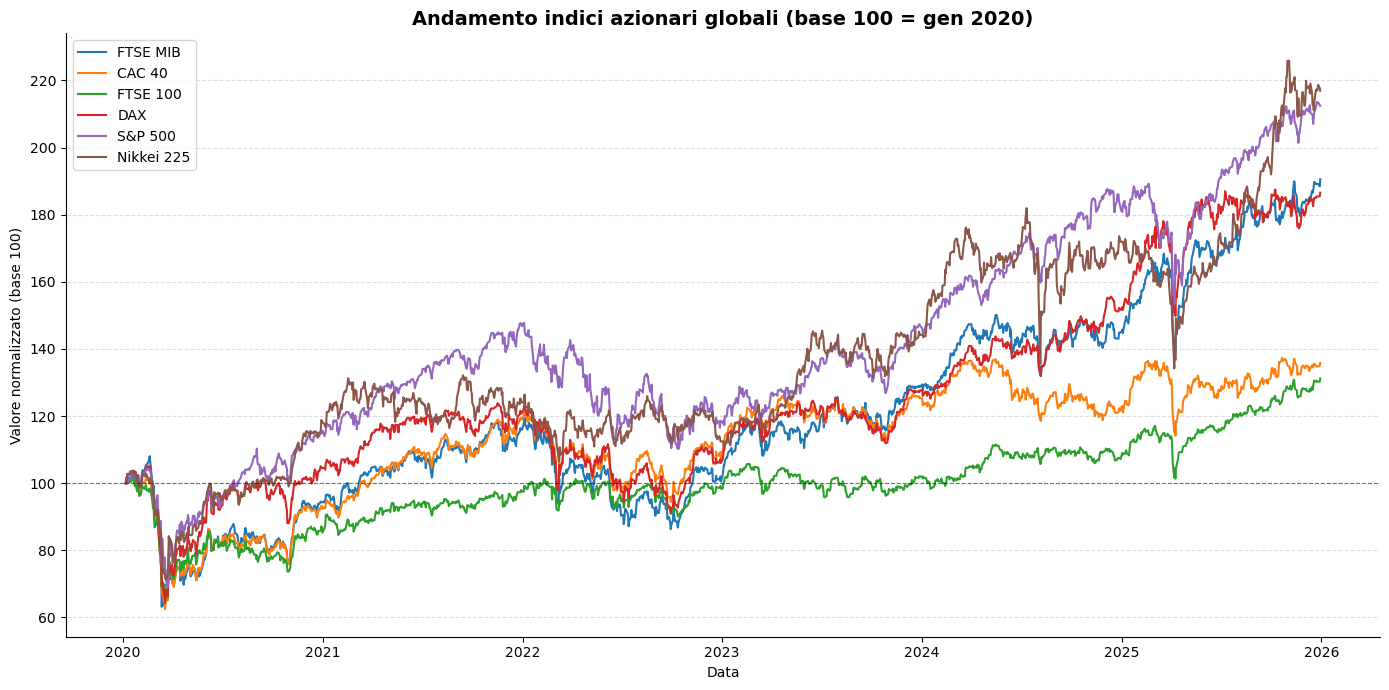

In [19]:
fig, n1 = plt.subplots(figsize=(14, 7))

for colonna in df_normalizzato.columns:
    n1.plot(df_normalizzato.index, df_normalizzato[colonna], label=colonna, linewidth=1.5)

# linea base 100
n1.axhline(y=100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

n1.set_title('Andamento indici azionari globali (base 100 = gen 2020)', fontsize=14, fontweight='bold')
n1.set_ylabel('Valore normalizzato (base 100)')
n1.set_xlabel('Data')
n1.legend(loc='upper left')
n1.grid(axis='y', linestyle='--', alpha=0.4)
n1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Il grafico mostra l'andamento normalizzato dei sei principali indici dal gennaio 2020. Si distinguono chiaramente tre momenti chiave:

1. **Crash COVID — marzo 2020**: tutti gli indici scendono sotto 80, con il FTSE MIB che tocca il minimo più profondo (~58). La velocità del crollo è senza precedenti nella storia moderna dei mercati.
2. **Ripresa disomogenea 2020–2022**: S&P 500 e Nikkei recuperano rapidamente e superano i massimi pre-COVID già entro fine 2020. Il FTSE 100 rimane in territorio negativo per oltre un anno, penalizzato dall'effetto Brexit.
3. **Divergenza crescente dal 2023**: Nikkei 225 e S&P 500 chiudono rispettivamente a ~217 e ~212, mentre CAC 40 e FTSE 100 si fermano sotto 136 — meno del 36% di rendimento in cinque anni.

## 2. Quali indici hanno reso di più nel periodo e quali di meno?

In [20]:
rendimenti = ((df_close.iloc[-1] - df_close.iloc[0])/df_close.iloc[0] * 100).round(2).sort_values(ascending=False)

for indice, rendimento in rendimenti.items():
    print(f"Il rendimento dal {df_close.index[0].date()} al {df_close.index[-1].date()} per l'indice {indice} è del {rendimento}%")

Il rendimento dal 2020-01-06 al 2025-12-30 per l'indice Nikkei 225 è del 116.94%
Il rendimento dal 2020-01-06 al 2025-12-30 per l'indice S&P 500 è del 112.44%
Il rendimento dal 2020-01-06 al 2025-12-30 per l'indice FTSE MIB è del 90.6%
Il rendimento dal 2020-01-06 al 2025-12-30 per l'indice DAX è del 86.57%
Il rendimento dal 2020-01-06 al 2025-12-30 per l'indice CAC 40 è del 35.83%
Il rendimento dal 2020-01-06 al 2025-12-30 per l'indice FTSE 100 è del 31.23%


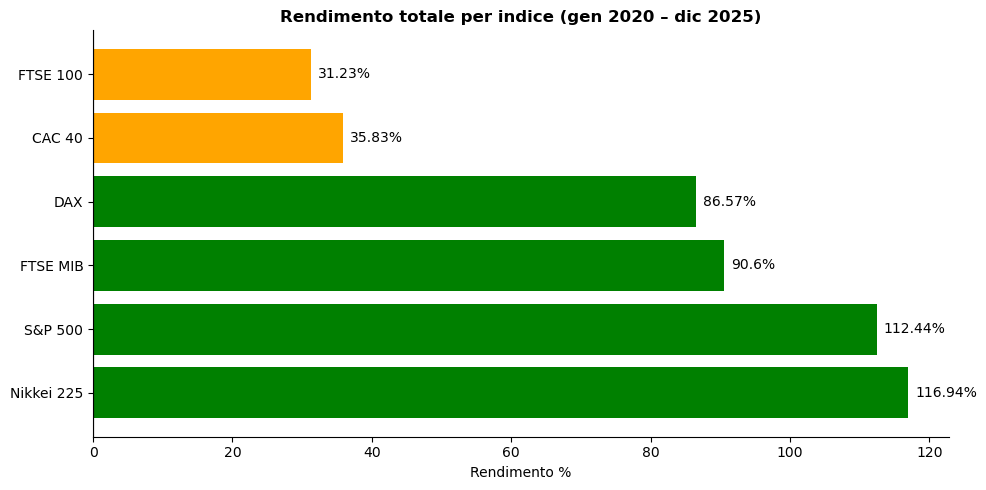

In [21]:
fig, n2 = plt.subplots(figsize=(10, 5))

colori = ['green' if r > 50 else 'orange' if r > 30 else 'tomato' 
          for r in rendimenti.values]

n2.barh(rendimenti.index, rendimenti.values, color=colori)
n2.axvline(x=0, color='black', linewidth=0.8)
n2.set_title('Rendimento totale per indice (gen 2020 – dic 2025)', fontweight='bold')
n2.set_xlabel('Rendimento %')
n2.spines[['top', 'right']].set_visible(False)

for i, (idx, val) in enumerate(rendimenti.items()):
    n2.text(val + 1, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Nel periodo gennaio 2020 – dicembre 2025 il **Nikkei 225** e l'**S&P 500** sono i migliori performer con rendimenti superiori al 110%, trainati rispettivamente dalla debolezza dello yen favorevole alle esportazioni giapponesi e dalla concentrazione dell'indice americano sui titoli tecnologici.  
**FTSE MIB** e **DAX** si attestano intorno all'88%, performance solida nel contesto europeo.  
**CAC 40** e **FTSE 100** chiudono sotto il 36% — il CAC penalizzato dall'instabilità politica francese del 2024, il FTSE 100 strutturalmente svantaggiato dalla composizione settoriale priva di grandi titoli tecnologici e dall'effetto Brexit.

## 3. Quanto sono stati volatili?

La volatilità è calcolata come **deviazione standard dei rendimenti giornalieri annualizzata** (× √252, standard in ambito finanziario).  
Il boxplot mostra la distribuzione completa dei rendimenti giornalieri — scatola, code e outlier.

In [22]:
#remdimenti giornalieri
df_returns = df_close.pct_change().dropna()

# volatilità annualizzata (std giornaliera * √252 giorni di borsa)
volatilita = (df_returns.std() * np.sqrt(252) * 100).round(2).sort_values(ascending=False)

df_riepilogo = pd.DataFrame({'rendimento': rendimenti,'volatilita': volatilita})

df_riepilogo = df_riepilogo.sort_values('volatilita', ascending=False)

for indice, riga in df_riepilogo.iterrows():
    print(f"L'indice {indice} ha un rendimento del {riga['rendimento']:.2f}% e una volatilità del {riga['volatilita']:.2f}%")

L'indice FTSE MIB ha un rendimento del 90.60% e una volatilità del 21.53%
L'indice Nikkei 225 ha un rendimento del 116.94% e una volatilità del 21.45%
L'indice S&P 500 ha un rendimento del 112.44% e una volatilità del 20.58%
L'indice DAX ha un rendimento del 86.57% e una volatilità del 20.02%
L'indice CAC 40 ha un rendimento del 35.83% e una volatilità del 19.60%
L'indice FTSE 100 ha un rendimento del 31.23% e una volatilità del 16.37%


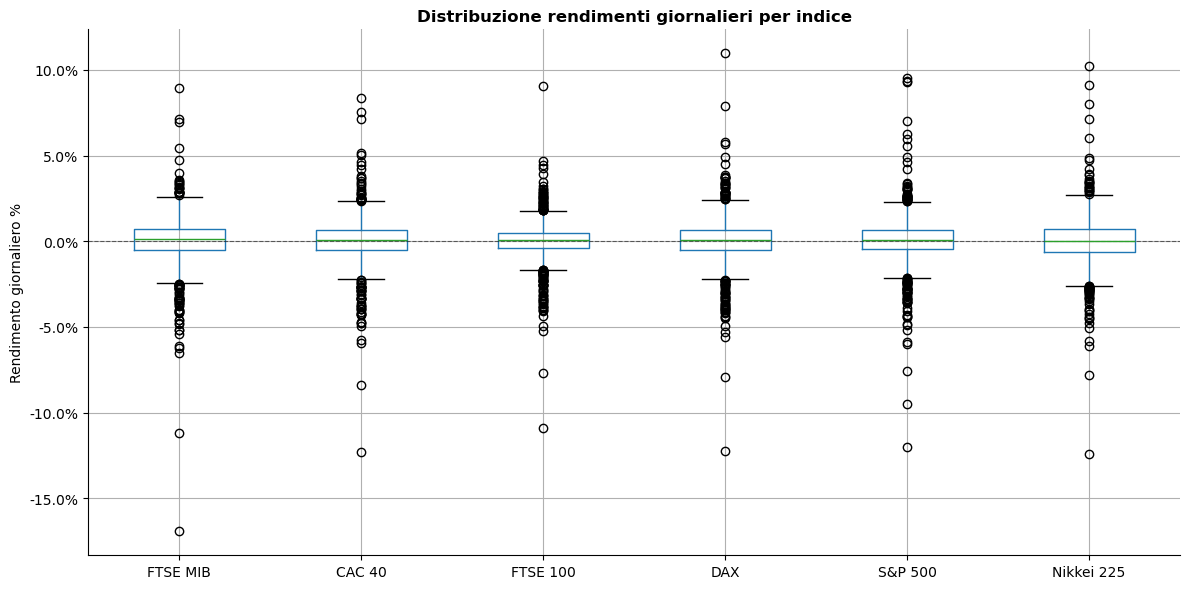

In [23]:
fig, n3 = plt.subplots(figsize=(12, 6))

df_returns.boxplot(ax=n3)

n3.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
n3.set_title('Distribuzione rendimenti giornalieri per indice', fontweight='bold')
n3.set_ylabel('Rendimento giornaliero %')
n3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))
n3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Le scatole di tutti gli indici sono compresse intorno allo 0% — il rendimento giornaliero mediano è praticamente zero per tutti, normale su orizzonti giornalieri.  
La vera differenza emerge nelle **code**: il FTSE MIB ha l'outlier negativo più estremo (~-17%, marzo 2020), confermando la sua maggiore volatilità annualizzata (21.53%). Il FTSE 100 ha le code più contenute, coerente con la volatilità più bassa del paniere (16.37%).  
Il **CAC 40** presenta un'anomalia: volatilità nella media (19.60%) ma rendimento tra i più bassi (35.83%), segnale di un profilo rischio/rendimento sfavorevole rispetto agli altri indici.

## 4. Quali sono stati i momenti di maggiore perdita?

Il **drawdown** misura di quanto un indice è sceso rispetto al suo massimo storico precedente.  
Risponde alla domanda: *"nel momento peggiore, quanto avrei perso se avessi investito al massimo?"*

In [24]:
#calcolo drawdown
df_drawdown = pd.DataFrame()

for indice in df_close.columns:
    massimo_storico = df_close[indice].cummax()
    #Per ogni giorno calcola il massimo storico raggiunto fino a quel momento dall'indice.
    df_drawdown[indice] = (df_close[indice] - massimo_storico) / massimo_storico * 100

#drawdown massimo per indice
max_drawdown = df_drawdown.min().round(2).sort_values()
max_drawdown_date = df_drawdown.idxmin()

for indice in max_drawdown.index:
    dd = max_drawdown[indice]
    data = max_drawdown_date[indice].strftime('%d/%m/%Y')
    print(f"L'indice {indice} ha avuto un drawdown massimo di {dd:.2f}% il {data}")

L'indice FTSE MIB ha avuto un drawdown massimo di -41.54% il 12/03/2020
L'indice DAX ha avuto un drawdown massimo di -38.78% il 18/03/2020
L'indice CAC 40 ha avuto un drawdown massimo di -38.56% il 18/03/2020
L'indice FTSE 100 ha avuto un drawdown massimo di -34.93% il 23/03/2020
L'indice S&P 500 ha avuto un drawdown massimo di -33.92% il 23/03/2020
L'indice Nikkei 225 ha avuto un drawdown massimo di -31.27% il 19/03/2020


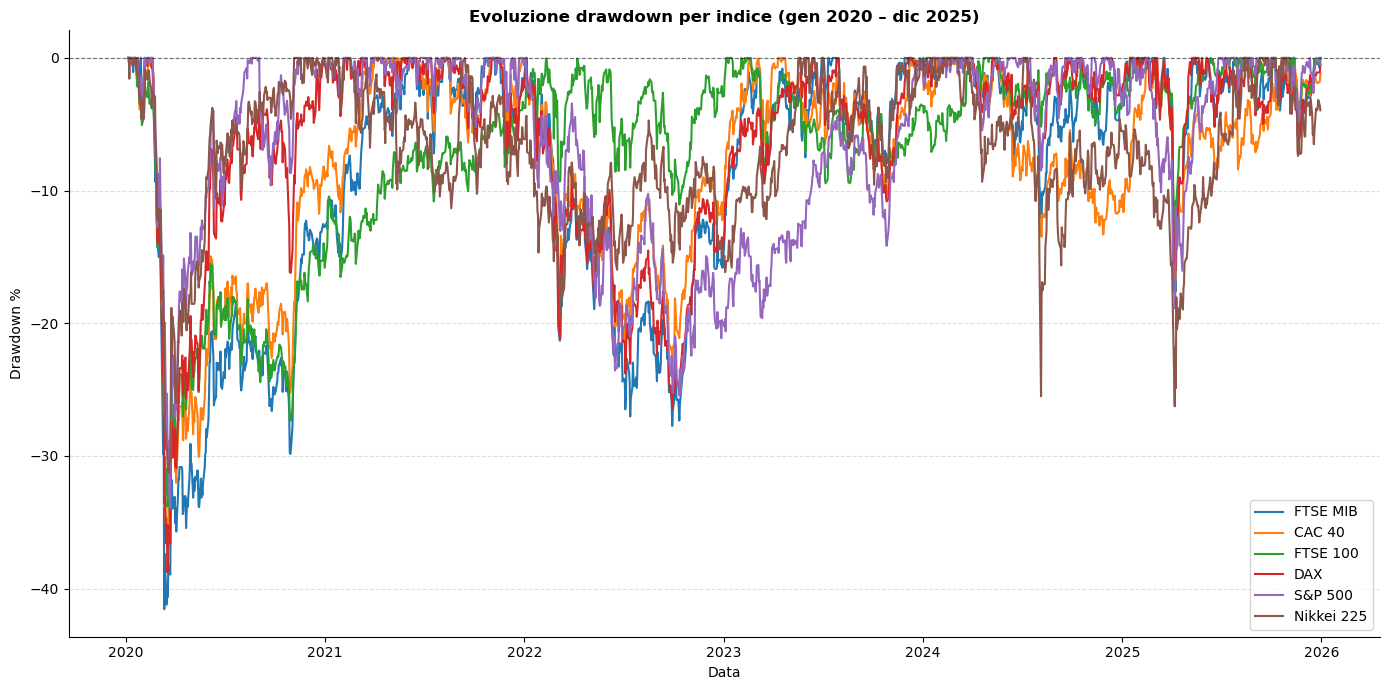

In [25]:
fig, n4 = plt.subplots(figsize=(14, 7))

for indice in df_drawdown.columns:
    n4.plot(df_drawdown.index, df_drawdown[indice], label=indice, linewidth=1.5)

n4.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
n4.set_title('Evoluzione drawdown per indice (gen 2020 – dic 2025)', fontweight='bold')
n4.set_ylabel('Drawdown %')
n4.set_xlabel('Data')
n4.legend(loc='lower right')
n4.grid(axis='y', linestyle='--', alpha=0.4)
n4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Il drawdown massimo di tutti e sei gli indici si concentra in una finestra di soli **11 giorni** — dal 12 al 23 marzo 2020 — corrispondente al picco del panico nella prima fase della pandemia COVID-19.  
Il **FTSE MIB** è stato il più colpito (-41.54%), probabilmente per l'esposizione dell'Italia come primo paese europeo investito duramente dalla pandemia. Il **Nikkei 225** ha subito il drawdown minore (-31.27%), beneficiando della risposta rapida del Giappone nella gestione sanitaria.  
Il grafico dell'evoluzione mostra una **seconda fase di stress nel 2022** (rialzo tassi Fed, guerra in Ucraina) con drawdown tra -15% e -30% per tutti gli indici, e una ripresa nuovamente divergente dal 2023.

## 5. Chi ha reso tanto rischiando poco?

Il **rapporto rendimento/volatilità** (Sharpe ratio semplificato, senza risk-free rate) misura quante unità di rendimento si ottengono per ogni unità di rischio assunto.  
Un valore più alto indica un profilo rischio/rendimento più efficiente.

In [26]:
#per rapporto rendimento/volatilità (chi rende di più per unità di rischio)
df_riepilogo['rendimento_per_rischio'] = (df_riepilogo['rendimento'] / df_riepilogo['volatilita']).round(2)
df_riepilogo.sort_values('rendimento_per_rischio', ascending=False)

,rendimento,volatilita,rendimento_per_rischio
S&P 500,112.44,20.58,5.46
Nikkei 225,116.94,21.45,5.45
DAX,86.57,20.02,4.32
FTSE MIB,90.60,21.53,4.21
FTSE 100,31.23,16.37,1.91
CAC 40,35.83,19.60,1.83


In [27]:
#aggiungiamo il max drawdown al riepilogo
df_riepilogo['max_drawdown'] = max_drawdown.abs()  # lo rendiamo positivo per leggibilità

#rapporto rendimento/volatilità (Sharpe semplificato senza risk-free rate)
df_riepilogo['rendimento_per_rischio'] = (df_riepilogo['rendimento'] / df_riepilogo['volatilita']).round(2)

df_riepilogo.sort_values('rendimento_per_rischio', ascending=False)

,rendimento,volatilita,rendimento_per_rischio,max_drawdown
S&P 500,112.44,20.58,5.46,33.92
Nikkei 225,116.94,21.45,5.45,31.27
DAX,86.57,20.02,4.32,38.78
FTSE MIB,90.60,21.53,4.21,41.54
FTSE 100,31.23,16.37,1.91,34.93
CAC 40,35.83,19.60,1.83,38.56


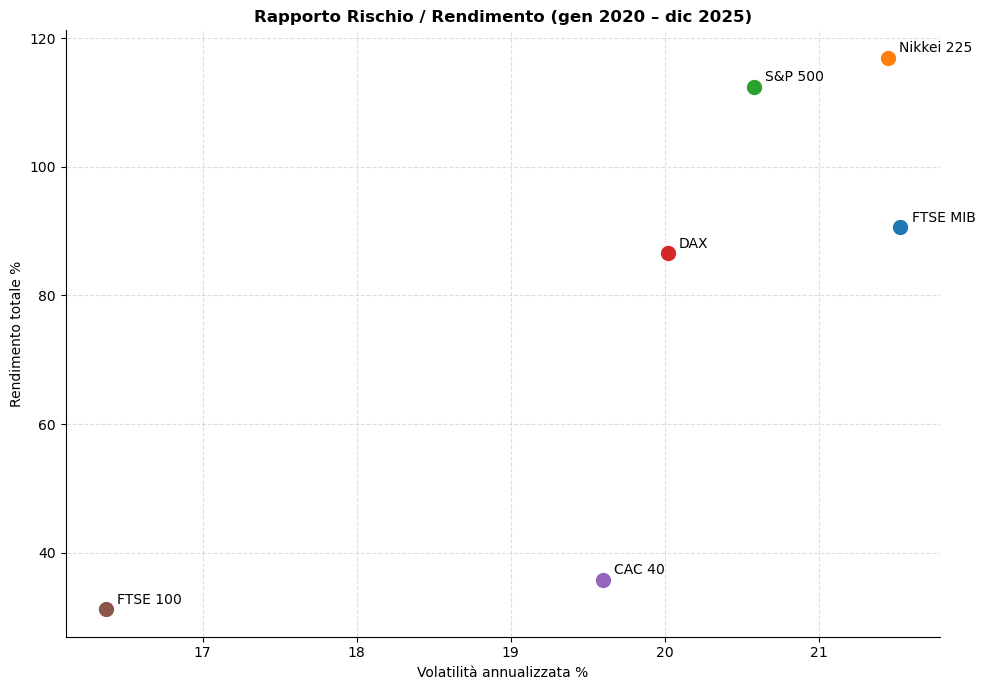

In [28]:
fig, n5 = plt.subplots(figsize=(10, 7))

for indice, riga in df_riepilogo.iterrows():
    n5.scatter(riga['volatilita'], riga['rendimento'], s=100, zorder=3)
    n5.annotate(indice, 
                xy=(riga['volatilita'], riga['rendimento']),
                xytext=(8, 4), 
                textcoords='offset points',
                fontsize=10)

n5.set_title('Rapporto Rischio / Rendimento (gen 2020 – dic 2025)', fontweight='bold')
n5.set_xlabel('Volatilità annualizzata %')
n5.set_ylabel('Rendimento totale %')
n5.grid(linestyle='--', alpha=0.4)
n5.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Lo scatter plot sintetizza l'intera analisi in un colpo solo. I punti in alto a sinistra rappresentano gli indici più efficienti — alto rendimento con bassa volatilità.

- **S&P 500 e Nikkei 225** occupano la posizione migliore: rendimenti superiori al 110% con volatilità intorno al 21%.
- **DAX** è il più efficiente tra gli europei: rendimento simile al FTSE MIB ma con volatilità inferiore.
- **FTSE MIB** è l'anomalia europea: stesso rendimento del DAX (~88%) ma volatilità più alta (21.53%) — più rischio per lo stesso risultato.
- **CAC 40 e FTSE 100** sono i peggiori in assoluto: basso rendimento con volatilità nella media, il profilo meno attraente del paniere.

## 6. Quanto si muovono insieme gli indici?

La **matrice di correlazione** mostra quanto i rendimenti giornalieri di due indici tendono a muoversi nella stessa direzione.  
Un valore vicino a 1 indica alta correlazione — diversificare tra indici molto correlati offre una riduzione del rischio limitata.

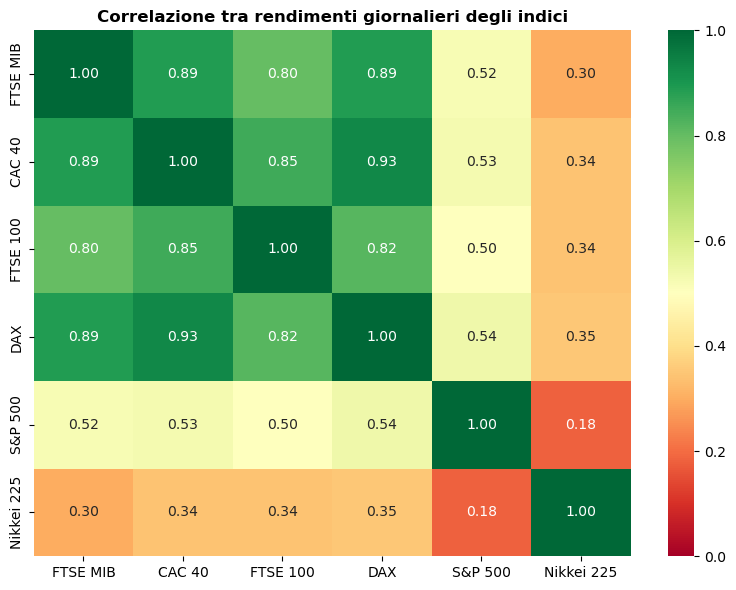

In [29]:
correlazione = df_returns.corr().round(2)

fig, n6 = plt.subplots(figsize=(8, 6))

sns.heatmap(correlazione, 
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            vmin=0, vmax=1,
            ax=n6)

n6.set_title('Correlazione tra rendimenti giornalieri degli indici', fontweight='bold')
plt.tight_layout()
plt.show()

La heatmap evidenzia tre cluster distinti:

1. **Indici europei altamente correlati** (0.80–0.93): FTSE MIB, CAC 40, FTSE 100 e DAX si muovono quasi all'unisono — diversificare tra mercati europei offre una riduzione del rischio limitata.
2. **S&P 500 moderatamente correlato** con l'Europa (0.50–0.54): il mercato americano mantiene una parziale indipendenza.
3. **Nikkei 225 il più decorrelato** (0.18–0.35): è teoricamente il miglior strumento di diversificazione del paniere — un investitore europeo che aggiunge il Nikkei riduce il rischio complessivo senza rinunciare al rendimento.

In [30]:
df_annualizzato = df_close.resample('YE').last() #resample è un groupby per le date (YearEnd)
rendimento_annuale = df_annualizzato.pct_change().dropna() * 100

print(rendimento_annuale.round(2))

            FTSE MIB  CAC 40  FTSE 100    DAX  S&P 500  Nikkei 225
Date                                                              
2021-12-31     23.00   28.85     14.30  15.79    26.89        4.91
2022-12-31    -13.31   -9.50      0.91 -12.35   -19.44       -9.37
2023-12-31     28.03   16.52      3.78  20.31    24.23       28.24
2024-12-31     12.63   -2.15      5.69  18.85    23.31       19.22
2025-12-31     31.47   10.67     21.63  23.01    17.25       26.18


## 7. Come è andato ogni anno?

Rendimento calcolato anno per anno tramite `resample('YE')` — confronto del prezzo di chiusura dell'ultimo giorno di borsa di ogni anno con quello dell'anno precedente.

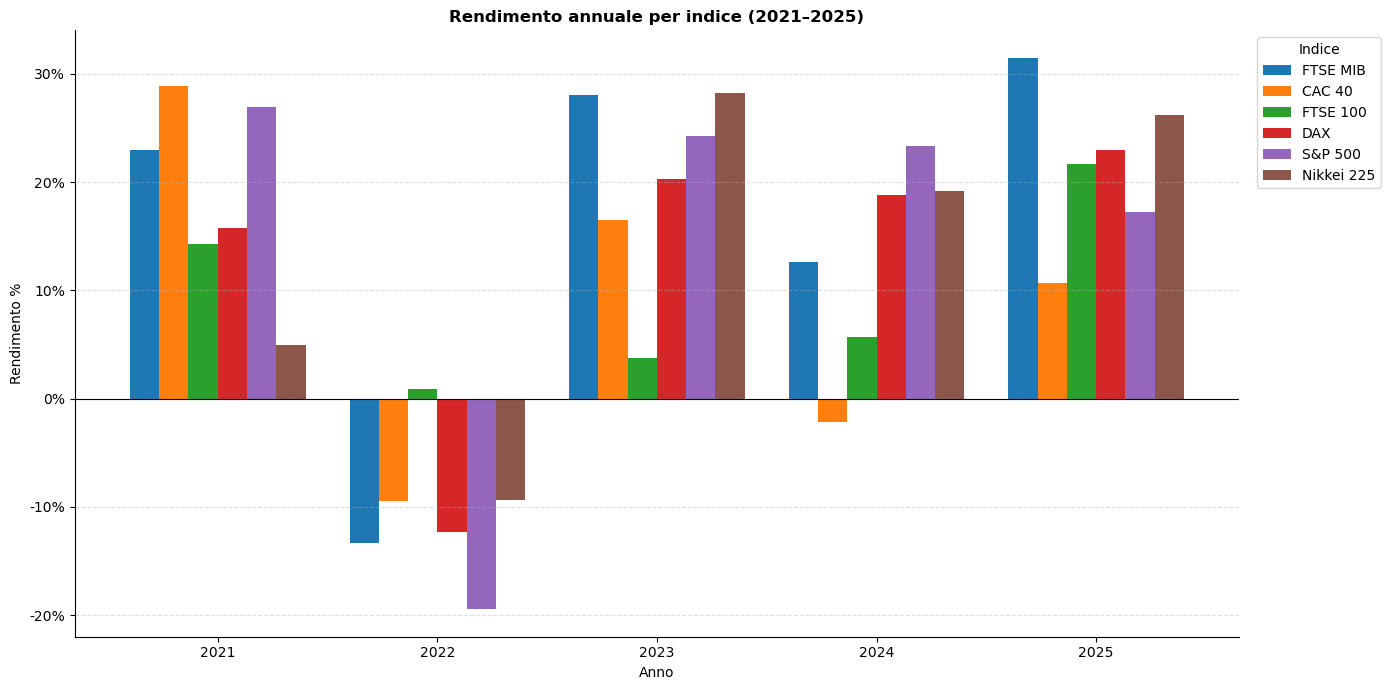

In [31]:
rendimento_annuale.index = rendimento_annuale.index.year

fig, n7 = plt.subplots(figsize=(14, 7))

rendimento_annuale.plot(kind='bar', ax=n7, width=0.8)

n7.axhline(y=0, color='black', linewidth=0.8)
n7.set_title('Rendimento annuale per indice (2021–2025)', fontweight='bold')
n7.set_xlabel('Anno')
n7.set_ylabel('Rendimento %')
n7.legend(title='Indice', bbox_to_anchor=(1.01, 1), loc='upper left')
n7.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
n7.grid(axis='y', linestyle='--', alpha=0.4)
n7.spines[['top', 'right']].set_visible(False)
n7.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

1. **2021**: anno positivo per tutti, CAC 40 a sorpresa in testa (+29%), Nikkei fanalino di coda (+5%).
2. **2022**: shock generalizzato — rialzo tassi Fed, inflazione e guerra in Ucraina. L'S&P 500 è il più colpito (-19%). Il **FTSE 100 è l'unica eccezione** (+1%), grazie alla composizione difensiva su energia e materie prime avvantaggiate dall'inflazione.
3. **2023**: ripresa forte e omogenea, FTSE MIB e Nikkei in testa (+28% entrambi).
4. **2024**: anno selettivo — CAC 40 in negativo (-2%) per l'instabilità politica francese, DAX e S&P 500 continuano a crescere.
5. **2025**: il **FTSE MIB è il miglior performer** (+31%), segnale di una rivalutazione del mercato italiano.